In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.bat_hd_system import BatHeadDirectionSystem, sphere_to_toroid
from grid_cells.plot_tools import angular_error, smooth_ts
import os
from concurrent.futures import ThreadPoolExecutor

DATA_DIR = "../simulation_data/hebb"
PLOTS_DIR = "../plots/hebb"
os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

In [2]:
T = 400
dt = 0.5e-3
n = 256
intrinsic_noise = 0.02
input_noise = 1
n_conj = 20
n_anchor = 20
interval = 100
bat_flight = generate_bat_flight(T=T, dt=dt)


net = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    anchor_strength = 5,
    gravity_gated=False,
)
net_anchor = BatHeadDirectionSystem(
    input_noise=input_noise,
    intrinsic_noise=intrinsic_noise,
    n_conjunctive=n_conj,
    n_anchor=n_anchor,
    gravity_gated=True,
)

net.warm_up(initial_dir=bat_flight["dir_torus"][0])
net_anchor.warm_up(initial_dir=bat_flight["dir_torus"][0])

n_steps = bat_flight["pos"].shape[0]

with ThreadPoolExecutor(max_workers=4) as executor:
    no_anchor_future = executor.submit(
        net.run_simulation, bat_flight["dir_vel"], interval=interval, verbose=False
    )

    anchor_future = executor.submit(
        net_anchor.run_simulation,
        bat_flight["dir_vel"],
        dir=bat_flight["dir_sphere"],
        save_weights=True,
        interval=interval,
        verbose=True,
    )
    recording = no_anchor_future.result()
    recording_anchor = anchor_future.result()

100%|██████████| 799999/799999 [00:52<00:00, 15315.66it/s]


Ran warm up for 140 steps
Ran warm up for 140 steps


Running Simulation Steps: 100%|██████████| 800000/800000 [06:20<00:00, 2102.16it/s]


In [3]:
np.savez(os.path.join(DATA_DIR, "recording"), **recording)
np.savez(os.path.join(DATA_DIR, "recording_anchor"), **recording_anchor)

In [4]:
np.mean(
    np.abs(
        angular_error(
            recording_anchor["decoded_angle"], bat_flight["dir_torus"][::interval]
        )
    ),
    axis=0,
), np.mean(
    np.abs(
        angular_error(recording["decoded_angle"], bat_flight["dir_torus"][::interval])
    ),
    axis=0,
)

(array([0.05929037, 0.05919285]), array([0.51081967, 0.6523368 ]))

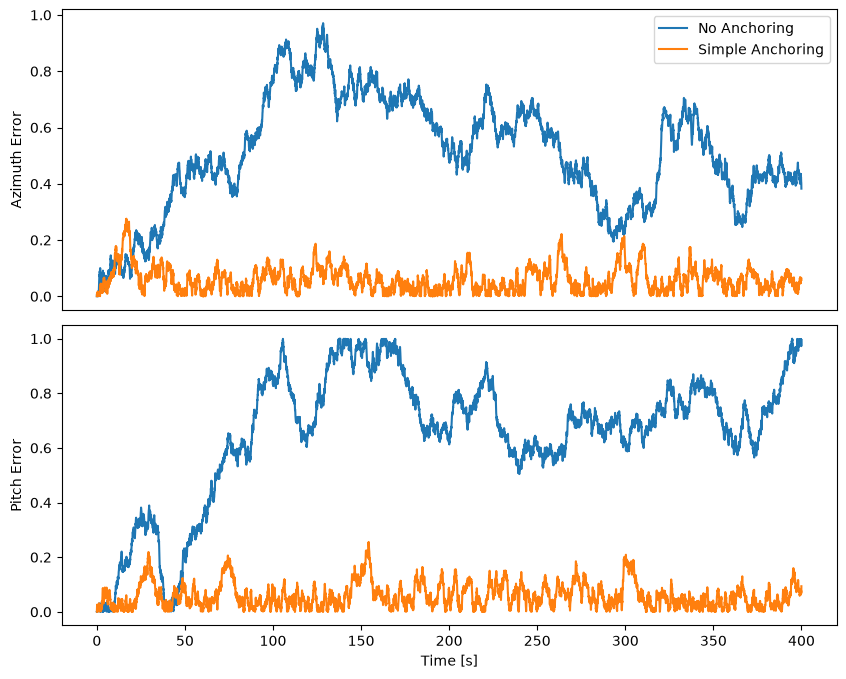

In [5]:
smooth_interval = 1
fig, ax = plt.subplots(
    nrows=2,
    figsize=(10, 8),
    sharex=True,
    gridspec_kw={"hspace": (0.05)},
)
for angle_iter, angle in enumerate(["Azimuth", "Pitch"]):
    simple_anchor_error = angular_error(
        recording_anchor["decoded_angle"][:, angle_iter],
        bat_flight["dir_torus"][::interval, angle_iter],
    )
    error = angular_error(
        recording["decoded_angle"][:, angle_iter],
        bat_flight["dir_torus"][::interval, angle_iter],
    )
    ax[1 * angle_iter].plot(
        smooth_ts(bat_flight["time"][::interval], smooth_interval),
        np.abs(smooth_ts(error, smooth_interval)),
        label="No Anchoring",
    )
    ax[1 * angle_iter].plot(
        smooth_ts(bat_flight["time"][::interval], smooth_interval),
        np.abs(smooth_ts(simple_anchor_error, smooth_interval)),
        label="Simple Anchoring",
    )

    ax[1 * angle_iter].set_ylabel(angle + " Error")

for axis_iter in range(len(ax) - 1):
    ax[axis_iter].get_xaxis().set_visible(False)


ax[0].legend()
ax[-1].set_xlabel("Time [s]")
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_anchoring_effect.svg"))

In [6]:
np.max(recording_anchor["conj_cells"])

np.float64(0.7372590341605195)

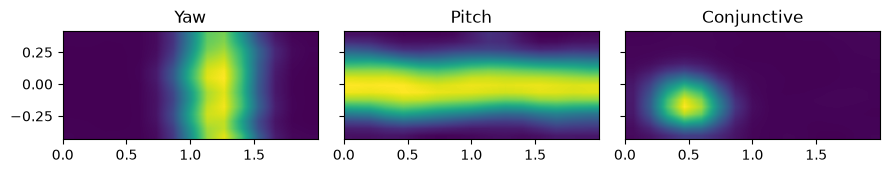

In [7]:
from grid_cells.plot_tools import activity_map

cell_index = 1
fig, ax = plt.subplots(ncols=3, sharey=True, figsize=(9, 4))
activity, counts, direction_edges = activity_map(
    bat_flight["dir_torus"][::interval],
    recording_anchor["yaw_cells"][:, 100],
    nbins=15,
    sigma=1,
)
ax[0].imshow(
    activity.T,
    extent=(
        direction_edges[0][0] / np.pi,
        direction_edges[0][-1] / np.pi,
        direction_edges[1][0] / np.pi,
        direction_edges[1][-1] / np.pi,
    ),
    origin="lower",
    interpolation="bilinear",
)
ax[0].set_title("Yaw")
activity, counts, direction_edges = activity_map(
    bat_flight["dir_torus"][::interval],
    recording_anchor["pitch_cells"][:, cell_index],
    nbins=15,
    sigma=1,
)

ax[1].imshow(
    activity.T,
    extent=(
        direction_edges[0][0] / np.pi,
        direction_edges[0][-1] / np.pi,
        direction_edges[1][0] / np.pi,
        direction_edges[1][-1] / np.pi,
    ),
    origin="lower",
    interpolation="bilinear",
)
ax[1].set_title("Pitch")

activity, counts, direction_edges = activity_map(
    bat_flight["dir_torus"][::interval],
    recording_anchor["conj_cells"][:, cell_index],
    nbins=15,
    sigma=1,
)
ax[2].imshow(
    activity.T,
    extent=(
        direction_edges[0][0] / np.pi,
        direction_edges[0][-1] / np.pi,
        direction_edges[1][0] / np.pi,
        direction_edges[1][-1] / np.pi,
    ),
    origin="lower",
    interpolation="bilinear",
)
ax[2].set_title("Conjunctive")
fig.tight_layout()
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_cell_types.svg"))

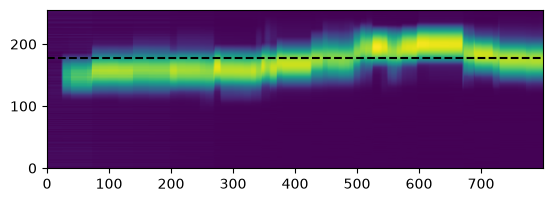

In [8]:
anchor_index = 0
inversion = 0
angle_index = 0
step = 10

yaw_anchor_weight = recording_anchor[f"{["yaw","pitch"][angle_index]}_anchor_weights"][
    ..., anchor_index, inversion
]
fig, ax = plt.subplots()
ax.imshow(yaw_anchor_weight[::step].T, origin="lower")
ax.axhline(
    net_anchor.yaw_ring.encode_orientation(
        sphere_to_toroid(*recording_anchor["anchor_angles"][anchor_index])[inversion][
            angle_index
        ]
    ).argmax(),
    c="black",
    ls="--",
)

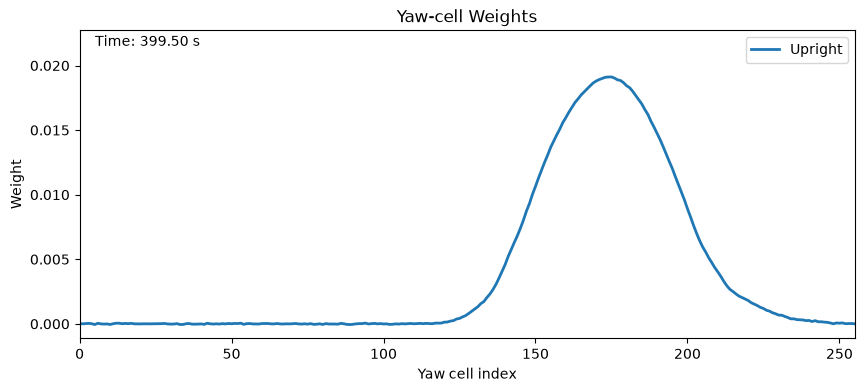

In [9]:
from matplotlib.animation import FuncAnimation, FFMpegWriter

# plt.rcParams["animation.ffmpeg_path"] = "/opt/homebrew/bin/ffmpeg"
yaw_anchor_weight = recording_anchor["yaw_anchor_weights"][..., 0, 0]

step = 10
frame_indices = np.arange(0, len(yaw_anchor_weight), step, dtype=int)

n_cells = yaw_anchor_weight.shape[1]
y_min, y_max = np.percentile(yaw_anchor_weight[::step], [1, 100])

margin = 0.05 * (y_max - y_min)

fig, ax = plt.subplots(figsize=(10, 4))
(line,) = ax.plot([], [], lw=2, label="Upright")


time_text = ax.text(0.02, 0.95, "", transform=ax.transAxes)

ax.set_xlim(0, n_cells - 1)
ax.set_ylim(y_min - margin, y_max + margin)
ax.set_xlabel("Yaw cell index")
ax.set_ylabel("Weight")
ax.set_title("Yaw-cell Weights")
ax.legend(loc="upper right")


def update(frame):
    index = frame_indices[frame]
    line.set_data(np.arange(n_cells), yaw_anchor_weight[index])
    time_text.set_text(f"Time: {bat_flight['time'][::interval][index]:.2f} s")
    return line, time_text


yaw_weight_animation = FuncAnimation(
    fig,
    update,
    frames=len(frame_indices),
    interval=40,
    blit=True,
)
FFwriter = FFMpegWriter(fps=25)
yaw_weight_animation.save(
    os.path.join(PLOTS_DIR, "bat_flight_yaw_weight_learning_simple.mp4"),
    writer=FFwriter,
)